## Selecting Ball Position
1. Generate random valid point (x_ball, y_ball) within green polygon (for testing purposes)

In [8]:
from shapely import wkt
import pandas as pd
import numpy as np
from shapely.geometry import Point

df = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/Map Digitisation/Mountain Meadows/MountainMeadows_Separated/hole_9/hole_9_data.csv")
green_info = df[df["lie"] == "green"].iloc[0]
green_shape = wkt.loads(green_info["WKT"])

def sample_point_on_green(green_shape):
    # get the bounds of the green shape
    minx, miny, maxx, maxy = green_shape.bounds

    while True:
        # randomly generate random coordinate
        x_ball = np.random.uniform(minx, maxx)
        y_ball = np.random.uniform(miny, maxy)
        # check whether point is on green
        if green_shape.contains(Point(x_ball, y_ball)):
            return (x_ball, y_ball)

## Computing Midpoints Slope Along Line

1. Computing 50% and 70% points along the line from the pin to the cup
$$x_t = x_{\text{ball}} + t \cdot (x_{\text{pin}}-x_{\text{ball}})$$
$$y_t = y_{\text{ball}} + t \cdot (y_{\text{pin}}-y_{\text{ball}})$$

2. Computing the gradient vector at $(x_{50}, y_{50})$ etc
$$\Delta z = (dz/dx, dz/dy)$$
by interpolating

3. Computing slope parallel (uphill/downhill) + perpendicular (sideways) to direction of putt 
$$\text{Direction of putt} = \vec{v} = \text{pin} - \text{ball} $$

Normalising
$$ \vec{u}_{\text{parallel}} = \frac{\vec{v}}{\| \vec{v} \| }$$
$$ \vec{u}_{\text{perp}} = (-u_y, u_x)$$

4. Projecting gradient to directions to get slope
$$\begin{align*} \text{slope}_{\text{parallel}} & = \Delta z \cdot \vec{u}_{\text{parallel}} \\
\text{slope}_{\text{perp}} & = \Delta z \cdot \vec{u}_{\text{perp}}
\end{align*}$$

MULTIPLY BY 100 TO GET SLOPE PERCENT!


In [9]:
#For multipliers
# used to interpolate 
def linear_scale(x, x_min, x_max, y_min, y_max):
    """Linearly interpolate y from x ∈ [x_min, x_max] to y ∈ [y_min, y_max]"""
    x = min(max(x, x_min), x_max)  # clamp to range
    return y_min + (x - x_min) / (x_max - x_min) * (y_max - y_min)

In [35]:
def t_along_position(ball_position, pin_position, t):
    '''
     Coordinate t% of the way to the pin, given ball position and pin position
    '''
    (x_ball, y_ball) = ball_position
    (x_pin, y_pin) = pin_position
    dp = t / 100
    return (x_ball + dp*(x_pin - x_ball), y_ball + dp*(y_pin - y_ball))


# From greensimtwotier file -------- reconstructs the elevation surface of the green
def green_contour(x, y):
    # Define a tiered green using tanh + sine for curvature
    curve_center = 185 + 3 * np.sin(0.1 * x)
    tier_height = 0.3
    tier_width = 3
    curved_tier = (tier_height / 2) * (np.tanh((y - curve_center) / tier_width) + 1)

    # Cosine bumps (upper-left = ridge, lower-right = depression)
    def cosine_bump(xc, yc, amp, rad):
        r2 = (x - xc)**2 + (y - yc)**2
        return np.where(r2 < rad**2, amp * 0.5 * (1 + np.cos(np.pi * np.sqrt(r2) / rad)), 0)

    upper_left = cosine_bump(-10, 195, 0.15, 10)
    lower_right = -cosine_bump(5, 170, 0.27, 15)

    # Global tilt (l to r and front to back)
    tilt = 0.015 * x + 0.00003 * y

    return curved_tier + upper_left + lower_right + tilt

# Creating X, Y grid over the green
minx, miny, maxx, maxy = green_shape.bounds
x_vals = np.linspace(minx, maxx, 300)
y_vals = np.linspace(miny, maxy, 300)
X, Y = np.meshgrid(x_vals, y_vals)

Z = green_contour(X,Y)

dy, dx = np.gradient(Z, y_vals, x_vals)
# ----------------------------

# To interpolate missing values
from scipy.interpolate import RegularGridInterpolator 
dx_interp = RegularGridInterpolator((y_vals, x_vals), dx)
dy_interp = RegularGridInterpolator((y_vals, x_vals), dy)


def slope_rating(ball_position, pin_position):

    (x_ball, y_ball) = ball_position
    (x_pin, y_pin) = pin_position

    putt_vector = np.array(pin_position) - np.array(ball_position)

    parallel_unit_vector = putt_vector / np.linalg.norm(putt_vector)
    parallel_x, parallel_y = parallel_unit_vector
    perpendicular_unit_vector = (-parallel_y, parallel_x)

    (x_50, y_50) = t_along_position(ball_position, pin_position, 50)
    (x_70, y_70) = t_along_position(ball_position, pin_position, 70)
    (x_85, y_85) = t_along_position(ball_position, pin_position, 85)
    (x_95, y_95) = t_along_position(ball_position, pin_position, 95)
    
    slope_keys = [(x_50, y_50), (x_70, y_70), (x_85, y_85),  (x_95, y_95)]

    max_sideways = 0
    max_forward = 0

    for position in slope_keys:
        x, y = position
        grad_dx = dx_interp([[y, x]])[0]
        grad_dy = dy_interp([[y, x]])[0]

        slope_parallel = np.dot((grad_dx, grad_dy), parallel_unit_vector)
        slope_perp = np.dot((grad_dx, grad_dy), perpendicular_unit_vector)

        max_sideways = max(max_sideways, abs(slope_perp * 100)) #converting to slope by * 100
        max_forward = max(max_forward, abs(slope_parallel * 100))

    return (max_sideways, max_forward)

def side_slope_multiplier(ball_position, pin_position):
    max_side = abs(slope_rating(ball_position, pin_position)[0])
    if max_side < .5:
        return 1
    elif max_side < 1.0:
        return linear_scale(max_side, .5, 1, 1, 1.03)
    elif max_side < 2.0:
        return linear_scale(max_side, 1, 2, 1.04, 1.09)
    elif max_side < 3.0:
        return linear_scale(max_side, 2, 3, 1.1, 1.2)
    elif max_side < 4.0:
        return linear_scale(max_side, 3, 4, 1.2, 1.25)
    else:
        return 1.35
    
def uphill_downhill_multiplier(ball_position, pin_position):
    slope_parallel = slope_rating(ball_position, pin_position)[1]  
    if slope_parallel >= 0:  # Uphill
        if slope_parallel < 0.5:
            return 1.00
        elif slope_parallel < 1.0:
            return linear_scale(slope_parallel, 0.5, 1.0, 1.03, 1.05)
        elif slope_parallel < 3.0:
            return linear_scale(slope_parallel, 1.0, 3.0, 1.06, 1.10)
        else:
            return 1.10

    else:  # Downhill (slope_parallel < 0)
        slope_parallel = abs(slope_parallel)
        if slope_parallel < 0.5:
            return 1.01
        elif slope_parallel < 1.0:
            return linear_scale(slope_parallel, 0.5, 1.0, 1.02, 1.07)
        elif slope_parallel < 3.0:
            return linear_scale(slope_parallel, 1.0, 3.0, 1.10, 1.30)
        else:
            return 1.45


# Different Tier detection
- Basically whether the ball is on a significantly different height than the pin
Could be 1 tier, 2 tiers or multiple tiers, but the bigger this difference is, the more penalising it should be.
Rating different heights:
- SAME TIER: Difference less than .15
- Level 1 tier: Difference .15 - .45
- Level 2 tier: Difference .45 - .7
- Level 3 tier: Difference .7 - 1
- Level 4 tier: Difference 1 - 2
- Level 5 tier Difference 2 + 

In [11]:
def classify_tier_difference(ball_pos, pin_pos):
    height_ball = green_contour(*ball_pos)
    height_pin = green_contour(*pin_pos)
    tier_diff = height_ball - height_pin # neg value means downhill

    if abs(tier_diff) < 0.15:
        return 0, tier_diff
    elif abs(tier_diff) < .45:
        return 1, tier_diff
    elif abs(tier_diff) < .7:
        return 2, tier_diff
    elif abs(tier_diff) < 1:
        return 3, tier_diff
    elif abs(tier_diff) < 2:
        return 4, tier_diff
    else:
        return 5, tier_diff
    

def tier_multiplier(ball_position, pin_position):
    max_side = slope_rating(ball_position, pin_position)[0]
    if max_side < .5:
        return 1
    elif max_side < 1:
        return linear_scale(max_side, .5, 1, 1, 1.03)
    elif max_side < 2:
        return linear_scale(max_side, 1, 2, 1.04, 1.09)
    elif max_side < 3:
        return linear_scale(max_side, 2, 3, 1.1, 1.2)
    elif max_side < 4:
        return linear_scale(max_side, 3, 4, 1.2, 1.25)
    else:
        return 1.35

## Using GPR model to get predictive mean and standard deviation

In [17]:
from scipy.interpolate import interp1d

gpr_df = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 2/Green simulation/results/GPR_predictions_posterior.csv")

def euclidean_dis(pos_a, pos_b):
    x_a, y_a = pos_a
    x_b, y_b = pos_b
    return np.sqrt((x_b - x_a)**2 + (y_b - y_a)**2)

def raw_gpr_pred(ball_pos, pin_pos):
    putt_dis = euclidean_dis(ball_pos, pin_pos)
    gpr_df["posterior_std"] = (gpr_df["upper_95ci"] - gpr_df["lower_95ci"]) / (2 * 1.96)

    mean_interp = interp1d(gpr_df["distance_ft"], gpr_df["posterior_mean"], fill_value="extrapolate")
    std_interp = interp1d(gpr_df["distance_ft"], gpr_df["posterior_std"], fill_value="extrapolate")

    return mean_interp(putt_dis), std_interp(putt_dis)

## Applying Adjustments to GPR + Simulating Putts
| Factor        | Condition | Suggested Mean Change     |
| ------------- | --------- | ------------------------- |
| **Tier**      | 0         | x 1                       |
|               | 1         | x 1.05 - 1.07             |
|               | 2         | x 1.08 - 1.12             |
|               | 3         | x 1.12 - 1.17             |
|               | 4         | x 1.18 - 1.25                      |
|               | 5         | x 1.4                   |
| **Side-Slope**| <.5    |     x1                 |
|               |  .5- 1 |       x1 - 1.03              |                   
|               |  1 - 2 |       x1.04 - 1.09              |
|               |  3 - 4 |       x 1.1 - 1.2         |
|               |   4+   |           x1.35         |
| **Up/Downhill**| + <.5    |       x1               |
|               |  +.5- 1 |         x1.03 - 1.05            |                   
|               |  + 1.5 - 3 |     x1.06 - 1.10                |
|               |  + 3+ |             x1.10       |
|               |  - <.5    |     x1.01                 |
|               |  -.5- 1 |           x1.02 - 1.07          |                   
|               |  - 1.5 - 3 |        x1.10 - 1.30              |
|               |  - 3+ |               x1.3-1.6     |



In [14]:
# used to interpolate 
def linear_scale(x, x_min, x_max, y_min, y_max):
    """Linearly interpolate y from x ∈ [x_min, x_max] to y ∈ [y_min, y_max]"""
    x = min(max(x, x_min), x_max)  # clamp to range
    return y_min + (x - x_min) / (x_max - x_min) * (y_max - y_min)


In [27]:


def simulate_putt(ball_position, pin_position, seed = None, verbose=True):
    # if seed is not None:
    #     np.random.seed(seed)

    # Distance
    distance = np.sqrt((pin_position[0] - ball_position[0])**2 + (pin_position[1] - ball_position[1])**2)

    # Get raw GPR prediction
    mu, sigma = raw_gpr_pred(ball_position, pin_position)

    # Get multipliers
    tier_mult = tier_multiplier(ball_position, pin_position)
    side_mult = side_slope_multiplier(ball_position, pin_position)
    hill_mult = uphill_downhill_multiplier(ball_position, pin_position)

    # Combine and adjust
    total_mean_mult = tier_mult * side_mult * hill_mult
    mu_adj = mu * total_mean_mult

    total_std_mult = 0.85 * total_mean_mult + 0.15
    sigma_adj = sigma * total_std_mult

    # Sample
    simulated_avg = np.random.normal(mu_adj, sigma_adj)

    # Convert to putts
    if simulated_avg < 1.5:
        putts = 1
    elif simulated_avg < 2.5:
        putts = 2
    else:
        putts = 3

    # Print output
    if verbose:
        print(f"⛳ Ball Position: {ball_position}")
        print(f"📍 Pin Position:  {pin_position}")
        print(f"📏 Distance to Hole: {distance:.2f} ft")
        print(f"🎯 GPR Mean (μ):  {mu:.3f}")
        print(f"📊 GPR Std (σ):   {sigma:.3f}")
        print(f"➕ Tier Multiplier:       {tier_mult:.3f}")
        print(f"↔️  Side Slope Multiplier: {side_mult:.3f}")
        print(f"↕️  Up/Down Multiplier:    {hill_mult:.3f}")
        print(f"🎯 Adjusted Mean (μ'):  {mu_adj:.3f}")
        print(f"📊 Adjusted Std (σ'):   {sigma_adj:.3f}")
        print(f"🎲 Simulated Avg:      {simulated_avg:.3f}")
        print(f"⛳ → Estimated Putts:   {putts}")
        print("-" * 40)

    return putts


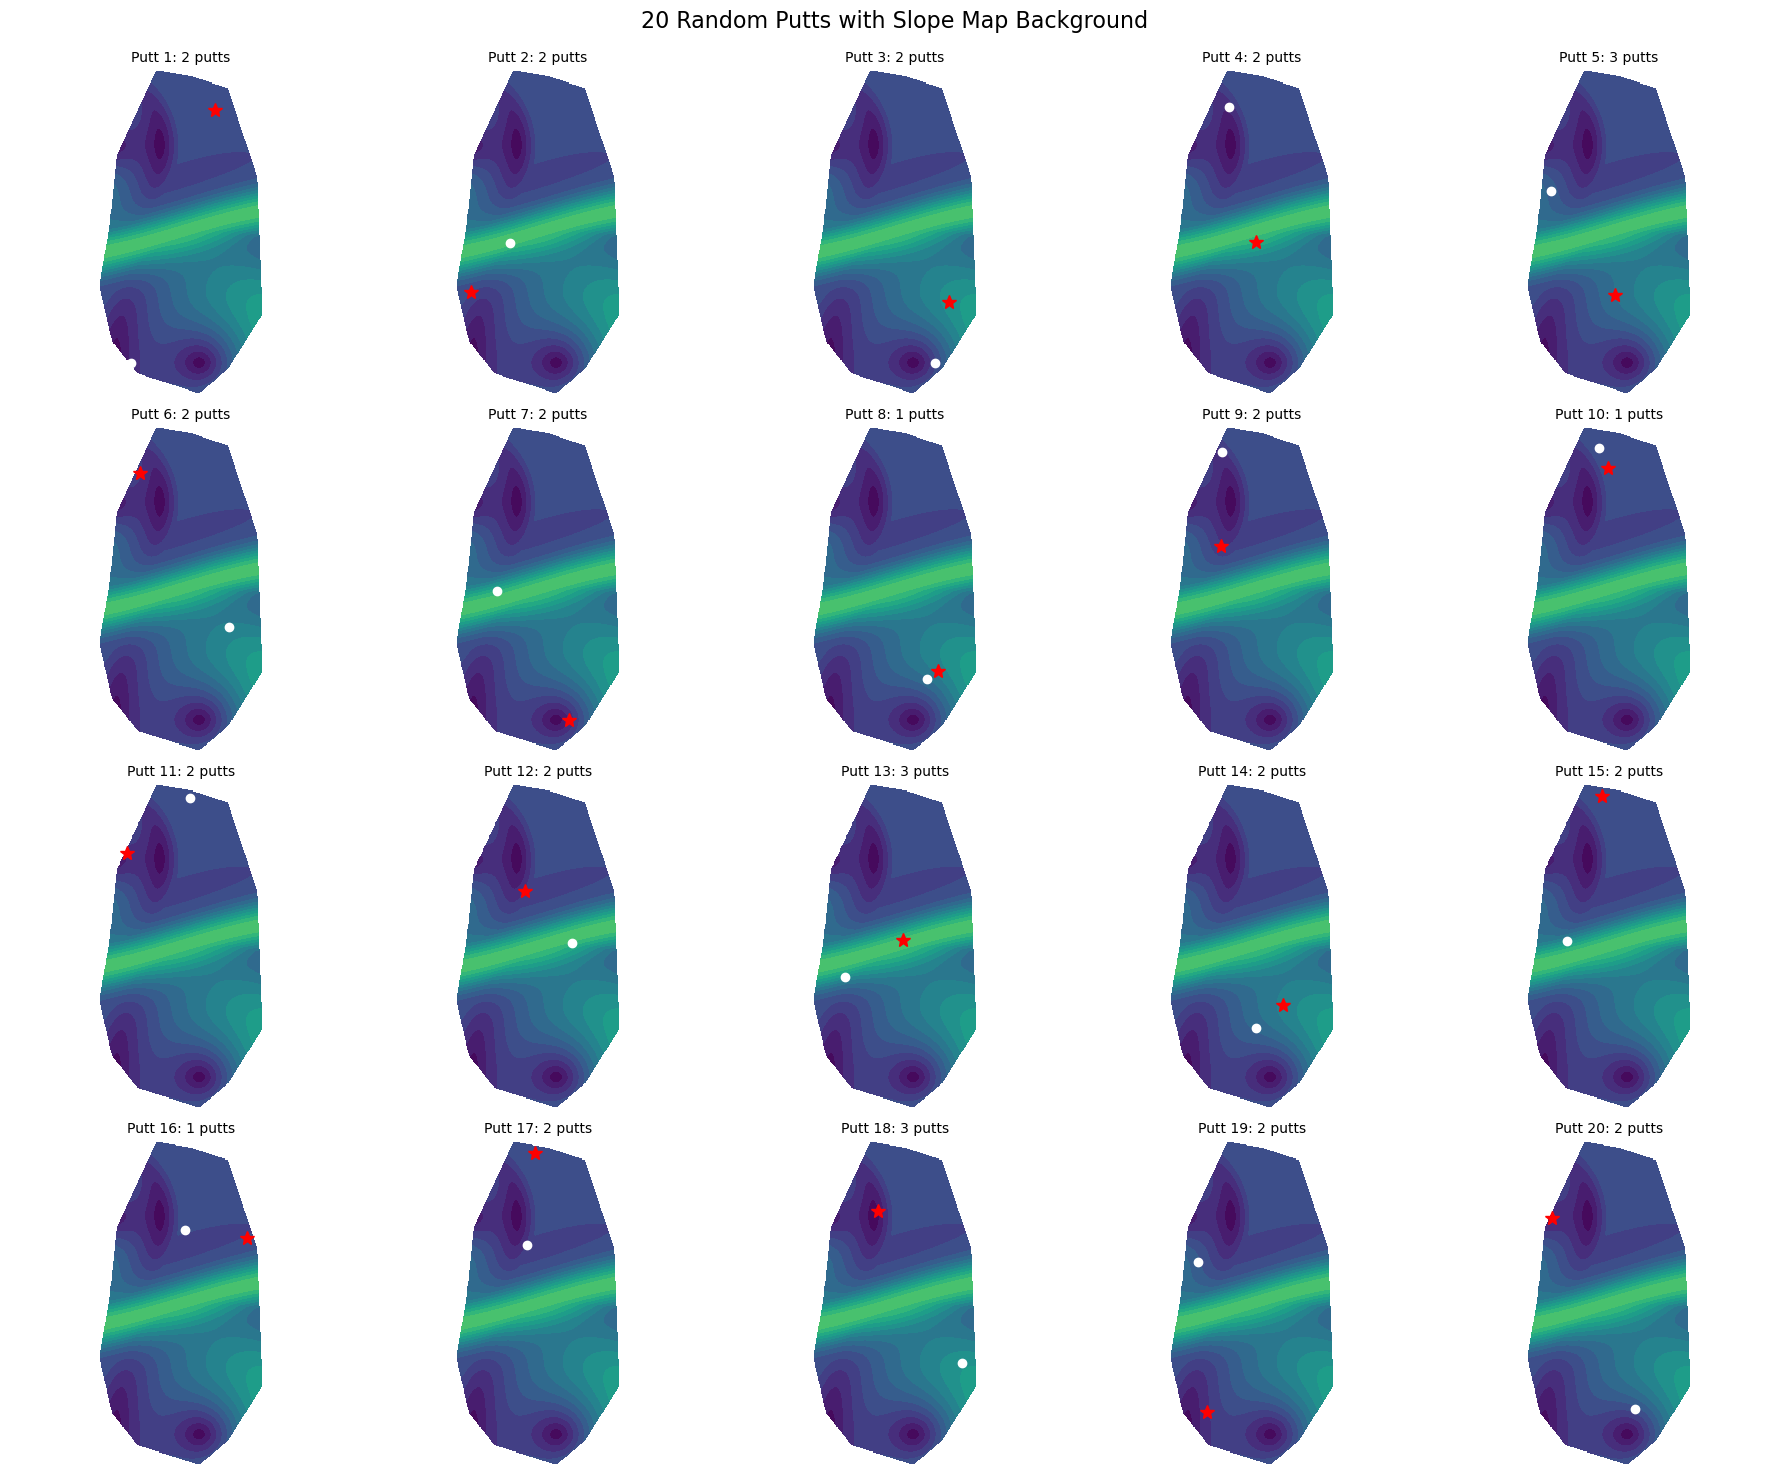

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely import wkt
from scipy.interpolate import griddata

# --- Load Green Shape ---
df = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/Map Digitisation/Mountain Meadows/MountainMeadows_Separated/hole_9/hole_9_data.csv")
green_info = df[df["lie"] == "green"].iloc[0]
green_shape = wkt.loads(green_info["WKT"])

# --- Create Grid ---
minx, miny, maxx, maxy = green_shape.bounds
x_vals = np.linspace(minx, maxx, 300)
y_vals = np.linspace(miny, maxy, 300)
X, Y = np.meshgrid(x_vals, y_vals)

# --- Define green surface again ---
def green_contour(x, y):
    curve_center = 185 + 3 * np.sin(0.1 * x)
    tier_height = 0.3
    tier_width = 3
    curved_tier = (tier_height / 2) * (np.tanh((y - curve_center) / tier_width) + 1)

    def cosine_bump(xc, yc, amp, rad):
        r2 = (x - xc)**2 + (y - yc)**2
        return np.where(r2 < rad**2, amp * 0.5 * (1 + np.cos(np.pi * np.sqrt(r2) / rad)), 0)

    upper_left = cosine_bump(-10, 195, 0.15, 10)
    lower_right = -cosine_bump(5, 170, 0.27, 15)
    tilt = 0.015 * x + 0.00003 * y

    return curved_tier + upper_left + lower_right + tilt

# --- Compute Slope ---
Z = green_contour(X, Y)
dy, dx = np.gradient(Z, y_vals, x_vals)
slope_percent = np.sqrt(dx**2 + dy**2) * 100
points = np.column_stack((X.ravel(), Y.ravel()))
mask = np.array([green_shape.contains(Point(x, y)) for x, y in points]).reshape(X.shape)
slope_percent[~mask] = np.nan  # Set values outside green to NaN

# --- Sample Valid Points on Green ---
def sample_point_on_green(green_shape):
    minx, miny, maxx, maxy = green_shape.bounds
    while True:
        x = np.random.uniform(minx, maxx)
        y = np.random.uniform(miny, maxy)
        if green_shape.contains(Point(x, y)):
            return (x, y)


# --- Plot 20 Simulations ---
fig, axs = plt.subplots(4, 5, figsize=(18, 15))
axs = axs.flatten()

for i in range(20):
    pin = sample_point_on_green(green_shape)
    ball = sample_point_on_green(green_shape)
    putts = simulate_putt(ball, pin, verbose = False)

    ax = axs[i]
    cp = ax.contourf(X, Y, slope_percent, levels=np.linspace(0, 7, 20), cmap='viridis')
    ax.plot(pin[0], pin[1], marker='*', color='red', markersize=10, label='Pin')
    ax.plot(ball[0], ball[1], marker='o', color='white', markersize=6, label='Ball')
    ax.set_title(f"Putt {i+1}: {putts} putts", fontsize=10)
    ax.axis('equal')
    ax.axis('off')

plt.suptitle("20 Random Putts with Slope Map Background", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()


/var/folders/vr/34gvhdpn06z_plwsw13j8w4c0000gn/T/ipykernel_45728/3285427318.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


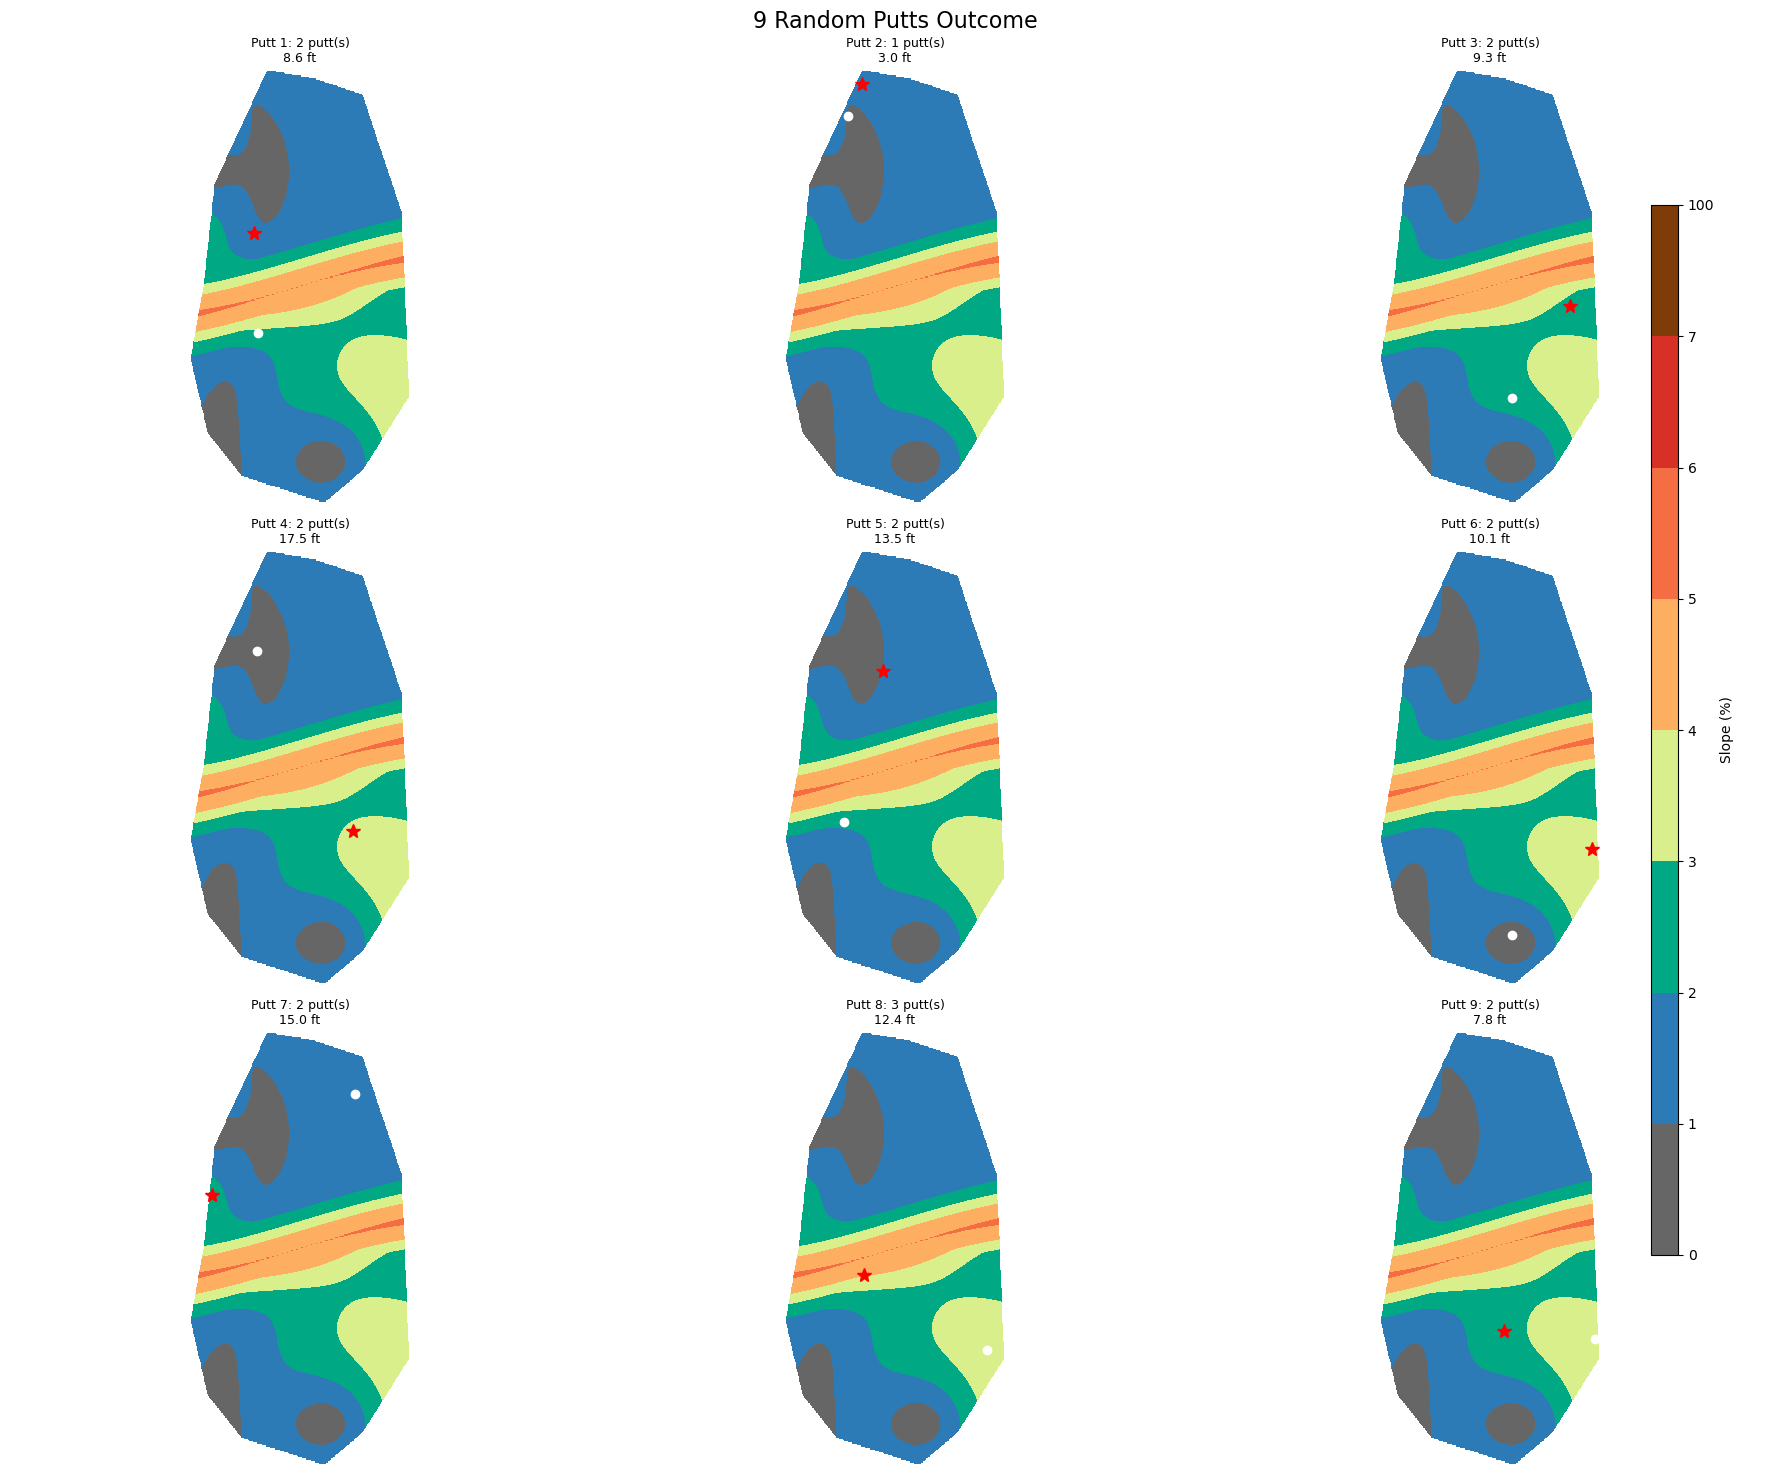

In [46]:
# With aimpoint colours

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely.geometry import Point
from shapely import wkt
from scipy.interpolate import griddata

# --- Load Green Shape ---
df = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/Map Digitisation/Mountain Meadows/MountainMeadows_Separated/hole_9/hole_9_data.csv")
green_info = df[df["lie"] == "green"].iloc[0]
green_shape = wkt.loads(green_info["WKT"])

# --- Create Grid ---
minx, miny, maxx, maxy = green_shape.bounds
x_vals = np.linspace(minx, maxx, 300)
y_vals = np.linspace(miny, maxy, 300)
X, Y = np.meshgrid(x_vals, y_vals)

# --- Define green surface again ---
def green_contour(x, y):
    curve_center = 185 + 3 * np.sin(0.1 * x)
    tier_height = 0.3
    tier_width = 3
    curved_tier = (tier_height / 2) * (np.tanh((y - curve_center) / tier_width) + 1)

    def cosine_bump(xc, yc, amp, rad):
        r2 = (x - xc)**2 + (y - yc)**2
        return np.where(r2 < rad**2, amp * 0.5 * (1 + np.cos(np.pi * np.sqrt(r2) / rad)), 0)

    upper_left = cosine_bump(-10, 195, 0.15, 10)
    lower_right = -cosine_bump(5, 170, 0.27, 15)
    tilt = 0.015 * x + 0.00003 * y

    return curved_tier + upper_left + lower_right + tilt

# --- Compute Slope ---
Z = green_contour(X, Y)
dy, dx = np.gradient(Z, y_vals, x_vals)
slope_percent = np.sqrt(dx**2 + dy**2) * 100
points = np.column_stack((X.ravel(), Y.ravel()))
mask = np.array([green_shape.contains(Point(x, y)) for x, y in points]).reshape(X.shape)
slope_percent[~mask] = np.nan  # Set values outside green to NaN

# --- Sample Valid Points on Green ---
def sample_point_on_green(green_shape):
    minx, miny, maxx, maxy = green_shape.bounds
    while True:
        x = np.random.uniform(minx, maxx)
        y = np.random.uniform(miny, maxy)
        if green_shape.contains(Point(x, y)):
            return (x, y)

puttview_colors = [
    "#666666", "#2c7bb6", "#00a884", "#d9ef8b",
    "#fdae61", "#f46d43", "#d73027", "#7f3b08"
]
boundaries = [0, 1, 2, 3, 4, 5, 6, 7, 100]
cmap = mcolors.ListedColormap(puttview_colors)
norm = mcolors.BoundaryNorm(boundaries, ncolors=cmap.N, clip=True)


# --- Plot 20 Simulations ---
fig, axs = plt.subplots(3, 3, figsize=(18, 15))
axs = axs.flatten()

for i in range(9):
    pin = sample_point_on_green(green_shape)
    ball = sample_point_on_green(green_shape)
    dist = np.sqrt((pin[0] - ball[0])**2 + (pin[1] - ball[1])**2)

    putts = simulate_putt(ball, pin, verbose = False)

    ax = axs[i]
    cp = ax.contourf(X, Y, slope_percent, levels=boundaries, cmap=cmap, norm=norm)
    ax.plot(pin[0], pin[1], marker='*', color='red', markersize=10, label='Pin')
    ax.plot(ball[0], ball[1], marker='o', color='white', markersize=6, label='Ball')
    ax.set_title(f"Putt {i+1}: {putts} putt(s)\n{dist:.1f} ft", fontsize=9)
    ax.axis('equal')
    ax.axis('off')

# Add a shared colorbar for the slope %
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
fig.colorbar(cp, cax=cbar_ax, ticks=boundaries, label='Slope (%)')

plt.suptitle("9 Random Putts Outcome", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()


# Plotting Expected Putts with Adjustment
